# Model Evaluation
In-depth model evaluation including confusion matrix heatmap, Precision-Recall curve, and financial impact risk analysis.

C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


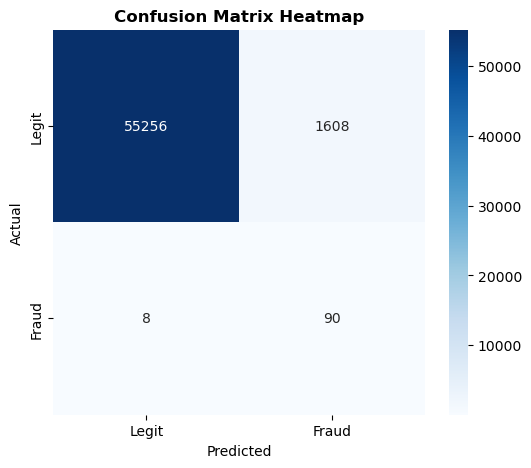

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_auc_score

credit_card_data = pd.read_csv('creditcard.csv' if os.path.exists('creditcard.csv') else 'creditcard.csv.zip')
X = credit_card_data.drop(columns='Class', axis=1)
y = credit_card_data['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42).fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title('Confusion Matrix Heatmap', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [2]:
# Financial Impact Analysis
tn, fp, fn, tp = cm.ravel()
avg_tx = 100
fp_cost = fp * (avg_tx * 0.10)   # $10 verification cost
fn_cost = fn * (avg_tx * 10.0)   # $1,000 unrecovered fraud loss
total_cost = fp_cost + fn_cost
print(f'False Positives (Verification alerts): {fp:,} -> Cost: ${fp_cost:,.2f}')
print(f'False Negatives (Missed Frauds):       {fn:,} -> Cost: ${fn_cost:,.2f}')
print(f'Total Financial Risk Cost:            ${total_cost:,.2f}')


False Positives (Verification alerts): 1,608 -> Cost: $16,080.00
False Negatives (Missed Frauds):       8 -> Cost: $8,000.00
Total Financial Risk Cost:            $24,080.00
